# Homework 4: Fitting data using SciPy

### <p style="text-align: right;"> &#9989; Put your name here</p>

# __CMSE  201 &ndash; Spring 2022__

<img src="https://cmse.msu.edu/sites/_cmse/assets/Image/image002.jpg"
     alt="CMSE Logo"
     align="right" 
     height="100" 
     width="100" />
     
## Goals

### By the end of the homework assignment you will have practiced:

1. Fitting curves using SciPy
2. Plotting data and the correspoding best-fit results
3. Calculating mean squared error when fitting a models to data

## Assignment instructions

Work through the following assignment, making sure to follow all of the directions and answer all of the questions.

**This assignment is due at 11:59pm on Friday, March 18.** 

It should be uploaded to D2L in the approach "Homework" submission folder.  Submission instructions can be found at the end of the notebook as well.

## Grading

- Academic Integrity (1 point)
- Question 0 (1 point)
- Question 1 (4 points)
- Question 2 (3 points)
- Question 3 (19 points)
- Question 4 (5 points)
- Question 5 (9 points)
- Question 6 (6 points)
- Question 7 (2 points)

**Total:** 50 points


---
# Academic integrity statement (1 point)

In the markdown cell below, put your personal academic integrity statement (composed during the Day04 In-Class Assignment). By including this statement, you are confirming that the work you submit in the assignment is wholly your own.  

<font size=6 color="#009600">&#9998;</font> *Put your personal academic integrity statement here.*

___


### &#9989;&nbsp; Question 0: Importing modules (1 point)

In this homework you're going to be using matplotlib, NumPy, and SciPy's `curve_fit` function, make sure you include all of the important and necessary `import` comments here.

In [1]:
# Put your code here

In [2]:
### ANSWER ###

# NumPy
import numpy as np
# Pyplot
import matplotlib.pyplot as plt
%matplotlib inline
# curve_fit from SciPy
from scipy.optimize import curve_fit

## 1. Generating Model Data

### &#9989;&nbsp; Question 1.1: (2 points)

In this homework, we will look at fitting higher order polynomials to data, and compare them to the linear fitting. We start with the simplest linear function $y(x) = 2x$ on the domain $0 \leq x \leq 1$.

We start by making an array of $x-values$ that spans from 0 to 1 with 21 points between the two values. Then, we define the linear function $y(x) = 2x$. We call the corresponding $y$-data generated from the function $y$ the *pure data.*

We will also generate a noisy data set $z$ by adding Gaussian noise with mean zero and standard deviation 0.1 to all of the $y$ values.

You are the given some of the codes.
```
x = ?
y = ?
np.random.seed(seed = 1)
noise = np.random.normal(0, 0.1, x.size)
z = y + noise
```
In the following cell, please **complete** the missing parts that marked as (?) in the given codes.

Notice: Here the code `np.random.seed(seed = 1)` fixes the seed that generats subsequent random numbers, so that the following `np.random.normal` picks one specific random sequence. **In this homework, for the sake of grading, you should always add this command each time right before generating random numbers like `noise`.**

In [3]:
# Put your code here

# x = ?
# y = ?
# np.random.seed(seed = 1)
# noise = np.random.normal(0, 0.1, x.size)
# z = y + noise

In [4]:
### ANSWER ###

# 1pt for each (?)

np.random.seed(seed = 1)
x = np.linspace(0, 1, 21)
y = x * 2
noise = np.random.normal(0, 0.1, x.size)
z = y + noise

### &#9989;&nbsp; Question 1.2: (2 points)

Create a **plot** of these two data sets ($y$ and $z$) by making two sub-plots with separated markers. Remember to add proper axes labels and titles.

In [5]:
# Put your code here

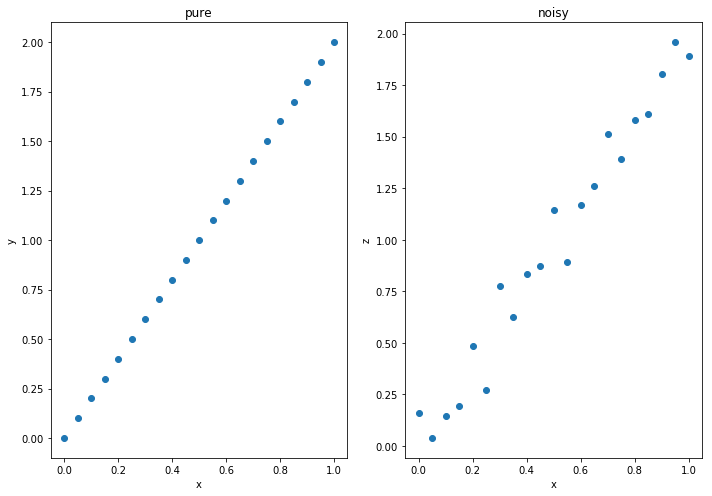

In [6]:
### ANSWER ###

# 2pts for subplots

plt.figure(figsize = (10, 7))

plt.subplot(1, 2, 1)
plt.title('pure')
plt.plot(x, y, 'o')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(1, 2, 2)
plt.title('noisy')
plt.plot(x, z, 'o')
plt.xlabel('x')
plt.ylabel('z')

plt.tight_layout()
plt.show()

## 2. Fitting Linear (1st-Order Polynomial) Models to Data

### &#9989;&nbsp; Question 2: (3 points)

In this question, you should use *scipy.optimize.curve_fit* function for these two data sets. 

Please fit linear functions to both of pure data and noisy data, and **plot** your predicted functions with the original data sets in sub-plots. Remember to add legends.

In [7]:
# Put your code here

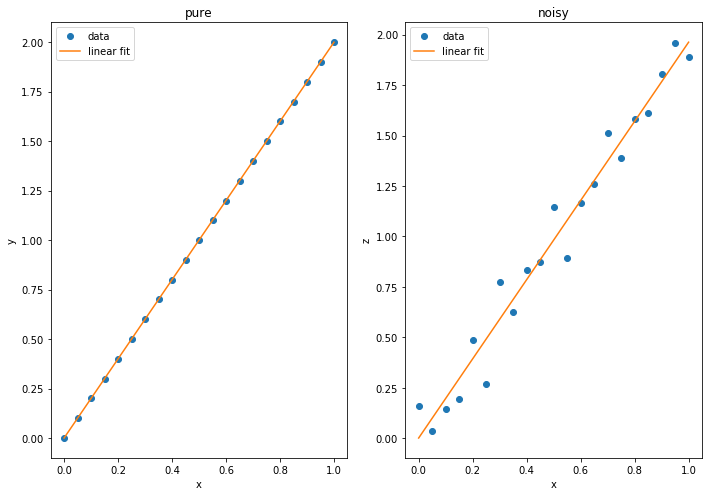

In [8]:
### ANSWER ###

# 1pt for using curve_fit
# 2pts for subplots

def my_fit_linear(coord, para0, para1):
    return para1 * coord + para0
popt_y, _ = curve_fit(my_fit_linear, x, y)
popt_z, _ = curve_fit(my_fit_linear, x, z)

plt.figure(figsize = (10, 7))

plt.subplot(1, 2, 1)
plt.title('pure')
plt.plot(x, y, 'o', label = 'data')
plt.plot(x, my_fit_linear(x, popt_y[0], popt_y[1]), label = 'linear fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.subplot(1, 2, 2)
plt.title('noisy')
plt.plot(x, z, 'o', label = 'data')
plt.plot(x, my_fit_linear(x, popt_z[0], popt_z[1]), label = 'linear fit')
plt.xlabel('x')
plt.ylabel('z')
plt.legend()

plt.tight_layout()
plt.show()

## 3. Exploring Linear Model Fits

### &#9989;&nbsp; Question 3.1: (4 points)

Please **print out** all the fitted model parameters for the pure data set in Question 2, and **answer** the following questions.
- For pure data, what are the expected fitted parameters? Please explain the reason.
- Do you get the exact parameters?

In [9]:
# Put your code here

<font size=+3>&#9998;</font> *Put your answers here.*
- answer
- answer

In [10]:
### ANSWER ###

# 1pt for printing out
# 2pts for answer 1
# 1pt for answer 2

print('Fitted model parameters for y is', popt_y)

# - The expected parameters should be [0, 2]. They are intercept and slope.
# - We get the exact parameters up to the machine error.

Fitted model parameters for y is [  7.08738689e-22   2.00000000e+00]


### &#9989;&nbsp; Question 3.2: (5 points)

Please **print out** all the fitted model parameters for the noisy data set in Question 2, and **answer** the following questions.
- For noisy data, what are the expected fitted parameters? Please explain the reason.
- Do you get the exact parameters?
- Are this result close to the answer in Questions 3.1?

In [11]:
# Put your code here

<font size=+3>&#9998;</font> *Put your answers here.*
- answer
- answer
- answer

In [12]:
### ANSWER ###

# 1pt for printing out
# 2pts for answer 1
# 1pt for answer 2
# 1pt for answer 3

print('Fitted model parameters for z is', popt_z)

# - The expected parameters should be still around [0, 1]. The data is almost like the linear one, so the expect values are slope and intercept.
# - We get something close but not exact.
# - They are somehow close to each other.

Fitted model parameters for z is [  1.79109204e-03   1.96053294e+00]


### &#9989;&nbsp; Question 3.3: (5 points)

Now, fit linear functions to the noisy data again just like Questions 1 and 2, but this time, we will use different noise options in `np.random.normal` for our noisy data, i.e., Gaussian noise with mean zero and standard deviation 0.01. Please **plot** your predicted functions with the new noisy data, **print out** the fitted model parameters, and **answer** the following questions.
- Comparing to the results you got in Question 2, what kind of change to the noisy data can you observe?
- Comparing to the results you got in Question 2, what kind of change to the fitted function can you observe?
- Comparing to the results you got in Question 3.2, what kind of change to the fitted model parameters can you observe?

In [13]:
# Put your code here

<font size=+3>&#9998;</font> *Put your answers here.*
- answer
- answer
- answer

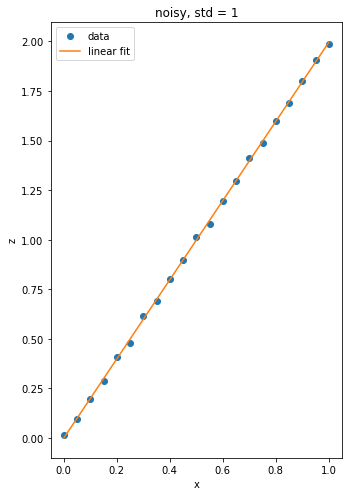

Fitted model parameters for z is [  1.79108911e-04   1.99605330e+00]


In [14]:
### ANSWER ###

# 1pt for code
# 1pt for each answer
# 1pt for parameters

np.random.seed(seed = 1)
noise = np.random.normal(0, 0.01, x.size)
z = y + noise

popt_y, _ = curve_fit(my_fit_linear, x, y)
popt_z, _ = curve_fit(my_fit_linear, x, z)

plt.figure(figsize = (5, 7))
plt.title('noisy, std = 1')
plt.plot(x, z, 'o', label = 'data')
plt.plot(x, my_fit_linear(x, popt_z[0], popt_z[1]), label = 'linear fit')
plt.xlabel('x')
plt.ylabel('z')
plt.legend()

plt.tight_layout()
plt.show()

print('Fitted model parameters for z is', popt_z)

# - The noisy data is closer to a linear pattern.
# - The fitted linear function has slope almost 2 and intercept almost 0.
# - The intercept is even closer to zero, and the slope is closer to 2.

### &#9989;&nbsp; Question 3.4: (5 points)

Fit linear functions to the noisy data again and take Gaussian noise with mean 2 and standard deviation 0.1. Please **plot** your predicted functions with the new noisy data, **print out** the fitted model parameters, and **answer** the following questions.
- Comparing to the results you got in Question 2, what kind of change to the noisy data can you observe?
- Comparing to the results you got in Question 2, what kind of change to the fitted function can you observe?
- Comparing to the results you got in Question 3.2, what kind of change to the fitted model parameters can you observe?

In [15]:
# Put your code here

<font size=+3>&#9998;</font> *Put your answers here.*
- answer
- answer
- answer

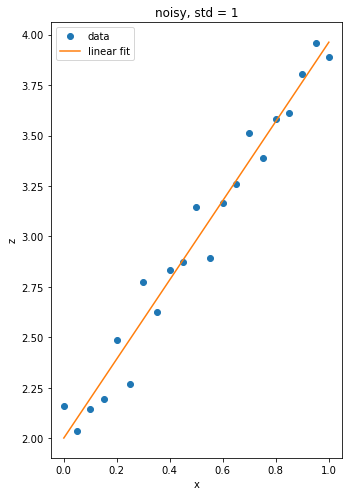

Fitted model parameters for z is [ 2.00179109  1.96053294]


In [16]:
### ANSWER ###

# 1pt for code
# 1pt for each answer
# 1pt for parameters

np.random.seed(seed = 1)
noise = np.random.normal(2, 0.1, x.size)
z = y + noise

popt_y, _ = curve_fit(my_fit_linear, x, y)
popt_z, _ = curve_fit(my_fit_linear, x, z)

plt.figure(figsize = (5, 7))
plt.title('noisy, std = 1')
plt.plot(x, z, 'o', label = 'data')
plt.plot(x, my_fit_linear(x, popt_z[0], popt_z[1]), label = 'linear fit')
plt.xlabel('x')
plt.ylabel('z')
plt.legend()

plt.tight_layout()
plt.show()

print('Fitted model parameters for z is', popt_z)

# - The noisy data is still linear, and shifts upward by 1 unit.
# - The fitted linear function is linear, with slope about 2 and intercept about 2.
# - The slope is exactly the same, and the intercept is added by 2.

## 4. Fitting Quartic (4th-Order Polynomial) Functions


### &#9989;&nbsp; Question 4.1: (1 points)

To improve the fitting, one idea is to add more parameters in the model, so that the model can be more flexible. For example, we can take polynomials with higher orders, say quardratic (2nd order) polynomials, cubic (3rd order) polynomials, quartic (4th order) polynomials, ... rather than linear (1st order) polynomials.

Let's try quartic (4th order) polynomials in this question. Here are some examples of quartic polynomials
$$
y(x) = 2x^4 - 3, \\
y(x) = 0.5x^4 + 1.75x^3 + 3x^2 - x + 7.
$$

Please **answer** the following question.
- How many (fit) parameters are there in a general quartic (4th order) polynomial?

<font size=+3>&#9998;</font> *Put your answer here.*
- answer

In [17]:
### ANSWER ###

# 1pt

# - There are five parameters, i.e., coefficients from 0th order to 4th order.

### &#9989;&nbsp; Question 4.2: (4 points)

Please fit quartic polynomials to pure data and the original noisy data (takeing Gaussian noise with mean zero and standard deviation 0.1). Please **plot** your new fitting functions based on the plots in Question 2. That is to say, plot two subplots for pure data and noisy data, and plot the linear fittings and the quartic fittings on them.

In [18]:
# Put your code here

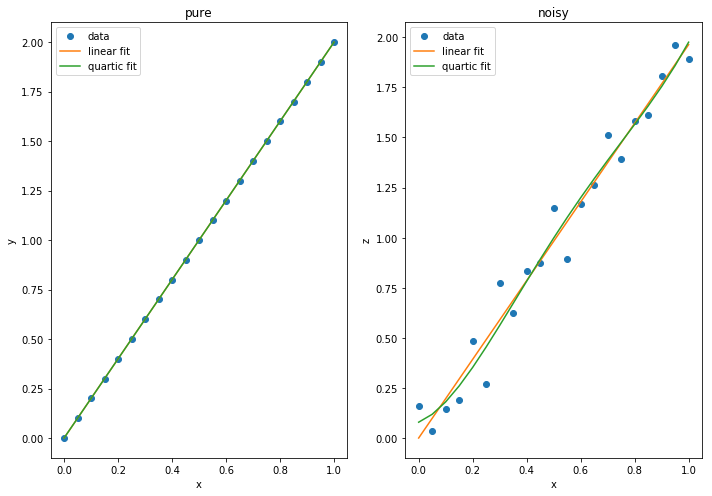

In [19]:
### ANSWER ###

# 1pt for quartic function
# 1pt for quartic fitting
# 2pts for subplots

np.random.seed(seed = 1)
noise = np.random.normal(0, 0.1, x.size)
z = y + noise

def my_fit_quartic(coord, para0, para1, para2, para3, para4):
    return para4 * coord ** 4 + para3 * coord ** 3 + para2 * coord ** 2 + para1 * coord + para0
def my_predict_linear(x, popt):
    return my_fit_linear(x, popt[0], popt[1])
def my_predict_quartic(x, popt):
    return my_fit_quartic(x, popt[0], popt[1], popt[2], popt[3], popt[4])

popt_y1, _ = curve_fit(my_fit_linear, x, y)
popt_z1, _ = curve_fit(my_fit_linear, x, z)
popt_y4, _ = curve_fit(my_fit_quartic, x, y)
popt_z4, _ = curve_fit(my_fit_quartic, x, z)

plt.figure(figsize = (10, 7))

plt.subplot(1, 2, 1)
plt.title('pure')
plt.plot(x, y, 'o', label = 'data')
plt.plot(x, my_predict_linear(x, popt_y1), label = 'linear fit')
plt.plot(x, my_predict_quartic(x, popt_y4), label = 'quartic fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.subplot(1, 2, 2)
plt.title('noisy')
plt.plot(x, z, 'o', label = 'data')
plt.plot(x, my_predict_linear(x, popt_z1), label = 'linear fit')
plt.plot(x, my_predict_quartic(x, popt_z4), label = 'quartic fit')
plt.xlabel('x')
plt.ylabel('z')
plt.legend()

plt.tight_layout()
plt.show()

## 5. Exploring Quartic Model Fits

### &#9989;&nbsp; Question 5.1: (5 points)

Please **print out** new fitted model parameters for the both data sets in Question 4, and **answer** the following questions:
- For pure data, what are the expected fitted parameters for the quartic polynomial? Please explain the reason. 
- Do you get the exact parameters?
- For quartic fitting to the noisy data, is that optimized parameter close to the one from the pure data?

In [20]:
# Put your code here

<font size=+3>&#9998;</font> *Put your answers here.*
- answer
- answer
- answer

In [21]:
### ANSWER ###

# 1pt for printing out
# 1pt for each answer

print('Fitted model parameters for y is', popt_y4)
print('Fitted model parameters for z is', popt_z4)

# - The expected parameters should be [0, 2, 0, 0, 0] (the order depends on the definition) since the original data is exact linear.
# - We get the exact parameters up to the machine error.
# - The two sets of parameters are not close at all.

Fitted model parameters for y is [  5.52009825e-09   1.99999988e+00   5.64501192e-07  -8.82685243e-07
   4.41265779e-07]
Fitted model parameters for z is [ 0.08060229  0.52709195  5.58802625 -7.66493202  3.44390239]


### &#9989;&nbsp; Question 5.2: (4 points)

Let's focus on the noisy data and its linear and quartic fittings you have found in Question 4. Please **plot** both fitted functions on a larger domain $-1 \leq x \leq 2$, and **answer** the following question:
- On the larger domain $-1 \leq x \leq 2$, do you think the quartic fitting is close to a linear function or not?
- Based on your fitted parameters and the expression of the quartic polynomial, which terms in the polynomial play a key role in the prediction at $x = 2$?
- In predicting values outside the range of data, which model is more sensitive to the noise, linear one or quartic one?

In [22]:
# Put your code here

<font size=+3>&#9998;</font> *Put your answers here.*
- answer
- answer
- answer

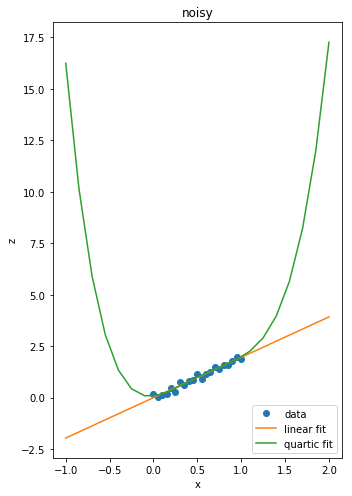

0.0806022852838
1.05418389135
22.3521049931
-61.3194561519
55.1024382718


In [23]:
### ANSWER ###

# 1pt for printing out
# 1pt for each answer

x_plot = np.linspace(-1, 2, 21)

plt.figure(figsize = (5, 7))

plt.title('noisy')
plt.plot(x, z, 'o', label = 'data')
plt.plot(x_plot, my_predict_linear(x_plot, popt_z1), label = 'linear fit')
plt.plot(x_plot, my_predict_quartic(x_plot, popt_z4), label = 'quartic fit')
plt.xlabel('x')
plt.ylabel('z')
plt.legend()

plt.tight_layout()
plt.show()

for i in range(5):
    print(popt_z4[i] * 2 ** i)

# - The quartic function fitted to the noisy data is far from linear, and blow up at the ends of the larger domain.
# - The quadratic term, cubic term, and the quartic terms play the key role.
# - The quartic model is more sensitive to the noise.

## 6. (Quantitatively) Evaluating the Model Fits


### &#9989;&nbsp; Question 6: (6 points)

A simple approach that evaluates the quality of the fitting is to measure the mean squared error (MSE). That is, given the data $\{ (a_i, b_i) \} _{i = 1} ^N$, and the fitted model $f$, we shall calculate the  mean squared error
$$ MSE := \frac{1}{N}\sum_{i=1}^{N} (f(a_i) - b_i) ^2.$$

First, please **write** function *MSE*, which has two inputs and one output:
- Input 1: the $y$ data $f(a)$ as a *numpy.ndarray*,
- Input 2: the model fit $y$-value $b$ as a *numpy.ndarray* (with the same size as Input 1),
- Output: the mean squared error $MSE$ as a *float*.

Then, **calculate** the MSE with respect to the data and fitted models we have done in Question 4:
1. pure data, with linear fit,
1. pure data, with quartic fit,
1. noisy data, with linear fit,
1. noisy data, with quartic fit.

Finally, **answer** the following question:
- When considering the noisy data, which fit model has less MSE? Please explain the reason.

In [24]:
# Put your code here

<font size=+3>&#9998;</font> *Put your answer here.*
- answer

In [25]:
### ANSWER ###

# 1pt for MSE function
# 1pt for each MSE calculation
# 1pt for each answer

def MSE(data, fit):
    return np.sum((data - fit) ** 2) / len(data)

popt_y1, _ = curve_fit(my_fit_linear, x, y)
popt_z1, _ = curve_fit(my_fit_linear, x, z)
popt_y4, _ = curve_fit(my_fit_quartic, x, y)
popt_z4, _ = curve_fit(my_fit_quartic, x, z)

print('When fitting linear function to the pure data, the MSE is '  + str(MSE(y, my_predict_linear(x, popt_y1))))
print('When fitting quartic function to the pure data, the MSE is ' + str(MSE(y, my_predict_quartic(x, popt_y4))))
print('When fitting linear function to the noisy data, the MSE is '  + str(MSE(z, my_predict_linear(x, popt_z1))))
print('When fitting quartic function to the noisy data, the MSE is ' + str(MSE(z, my_predict_quartic(x, popt_z4))))

# - When considering the noisy data, the Quartic fit model has less MSE, since the function space is larger, thus the minimizer is smaller.

When fitting linear function to the pure data, the MSE is 7.71522754214e-20
When fitting quartic function to the pure data, the MSE is 7.18258655441e-18
When fitting linear function to the noisy data, the MSE is 0.0118012492646
When fitting quartic function to the noisy data, the MSE is 0.0111246790461


## 7. Reflecting on Model Fitting

### &#9989;&nbsp; Question 7: (2 points)

The previous questions are based on artificial data, but for real-world data, the we will have the same question about how to choose the fitted model. Please **answer** the following questions:
- Is it true the models with more parameters (or with larger function space) is better?
- For real-world data, what kind of fitting models shall we choose?

<font size=+3>&#9998;</font> *Put your answers here.*
- answer
- answer

In [26]:
### ANSWER ###

# 1pt for each answer

# - No!
# - We should choose the models based on the model background. Focus on parameters with significance, and delete unnecessary parameters.

---

### Congratulations, you're done!

Submit this assignment by uploading it to the course Desire2Learn web page.  
Go to the "Homework Assignments" section, find the appropriate submission folder link, and upload it there.


&#169; Copyright 2022, [Department of Computational Mathematics, Science and Engineering](https://cmse.msu.edu) at Michigan State University.